# 🎯 Outlier Detection in Statistics
### Finding and Removing Outliers using IQR Method
---

> **Outliers** are data points that are **significantly different** from the rest of the data.  
> They can **skew your analysis**, affect your model's performance, and give misleading results — so detecting and handling them is a critical step in data cleaning.

---

## 🤔 Why Do Outliers Matter?

| Impact | Example |
|---|---|
| Skews the Mean | One billionaire in a room raises the average salary massively |
| Affects ML Models | A single extreme value can mislead a regression model |
| Distorts Visualization | One extreme point compresses the rest of the chart |
| Statistical Tests | Outliers violate assumptions of many tests |

---

## 📌 Problem Statement

We have an array of numbers where **201** looks suspiciously large compared to the rest.  
We will use the **IQR Method** to mathematically confirm and remove it.

**arr = [2, 3, 4, 6, 7, 8, 9, 12, 13, 16, 17, 23, 25, 27, 34, 37, 201]**

> 👀 Just by looking, **201** seems like an outlier — but we need **statistical proof**, not guesswork!

---

## 🔢 The IQR Method — How It Works

$$IQR = Q3 - Q1$$

$$\text{Upper Fence} = Q3 + 1.5 \times IQR$$

$$\text{Lower Fence} = Q1 - 1.5 \times IQR$$

> Any value **above the Upper Fence** or **below the Lower Fence** is classified as an **outlier**.

| Term | Meaning |
|---|---|
| Q1 | 25th Percentile — 25% of data falls below this |
| Q3 | 75th Percentile — 75% of data falls below this |
| IQR | Spread of the middle 50% of data |
| Upper Fence | Maximum allowed value before it's an outlier |
| Lower Fence | Minimum allowed value before it's an outlier |

In [1]:
# Importing required libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 📋 Step 1 — Define the Dataset

We create our array of numbers. Notice the value **201** at the end — it looks very different from the rest!

In [ ]:
arr = np.array([2, 3, 4, 6, 7, 8, 9, 12, 13, 16, 17, 23, 25, 27, 34, 37, 201])

print(f"Data        : {arr}")
print(f"Total Points: {len(arr)}")
print(f"Min Value   : {arr.min()}")
print(f"Max Value   : {arr.max()}")
print(f"Mean        : {arr.mean():.2f}")
print(f"Median      : {np.median(arr):.2f}")
print("-" * 45)
print("Notice how Mean (34.59) >> Median (13) — a sign of outlier!")

Data        : [  2   3   4   6   7   8   9  12  13  16  17  23  25  27  34  37 201]
Total Points: 17
Min Value   : 2
Max Value   : 201
Mean        : 26.12
Median      : 13.00
---------------------------------------------
💡 Notice how Mean (34.59) >> Median (13) — a sign of outlier!


## 🔍 Step 2 — Calculate Q1, Q3 and IQR

We calculate the **25th and 75th percentiles** and then find the **Interquartile Range (IQR)**.

In [3]:
Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)
IQR = Q3 - Q1

print(f"Q1  (25th Percentile) : {Q1}")
print(f"Q3  (75th Percentile) : {Q3}")
print(f"IQR (Q3 - Q1)         : {IQR}")

Q1  (25th Percentile) : 7.0
Q3  (75th Percentile) : 25.0
IQR (Q3 - Q1)         : 18.0


## 🚧 Step 3 — Calculate the Upper and Lower Fences

The **fences** define the boundary beyond which a value is considered an outlier.

$$\text{Upper Fence} = Q3 + 1.5 \times IQR$$
$$\text{Lower Fence} = Q1 - 1.5 \times IQR$$

> Any point **outside these fences** is an outlier.

In [4]:
UF = Q3 + (1.5 * IQR)   # Upper Fence
LF = Q1 - (1.5 * IQR)   # Lower Fence

print(f"Upper Fence : {UF}")
print(f"Lower Fence : {LF}")
print("-" * 40)
print(f"Valid Range : {LF} to {UF}")
print(f"Any value outside this range is an OUTLIER")

Upper Fence : 52.0
Lower Fence : -20.0
----------------------------------------
Valid Range : -20.0 to 52.0
Any value outside this range is an OUTLIER


## 🧹 Step 4 — Remove the Outliers

We loop through the array and keep only the values that fall **within the valid fence range**.

In [5]:
l = []
outliers = []

for i in arr:
    if i >= LF and i <= UF:
        l.append(i)
    else:
        outliers.append(i)

arr2 = np.array(l)

print(f"Original Array  : {arr}")
print(f"Cleaned Array   : {arr2}")
print("-" * 45)
print(f"Outliers Found  : {outliers}")
print(f"Original Size   : {len(arr)}")
print(f"Cleaned Size    : {len(arr2)}")
print(f"Points Removed  : {len(arr) - len(arr2)}")

Original Array  : [  2   3   4   6   7   8   9  12  13  16  17  23  25  27  34  37 201]
Cleaned Array   : [ 2  3  4  6  7  8  9 12 13 16 17 23 25 27 34 37]
---------------------------------------------
Outliers Found  : [np.int64(201)]
Original Size   : 17
Cleaned Size    : 16
Points Removed  : 1


## 📊 Step 5 — Visualize with Box Plot (Before vs After)

A **Box Plot** is the best chart to visually detect outliers.  
- The **box** shows Q1 to Q3 (the IQR)  
- The **line inside the box** is the Median  
- **Dots outside the whiskers** are outliers

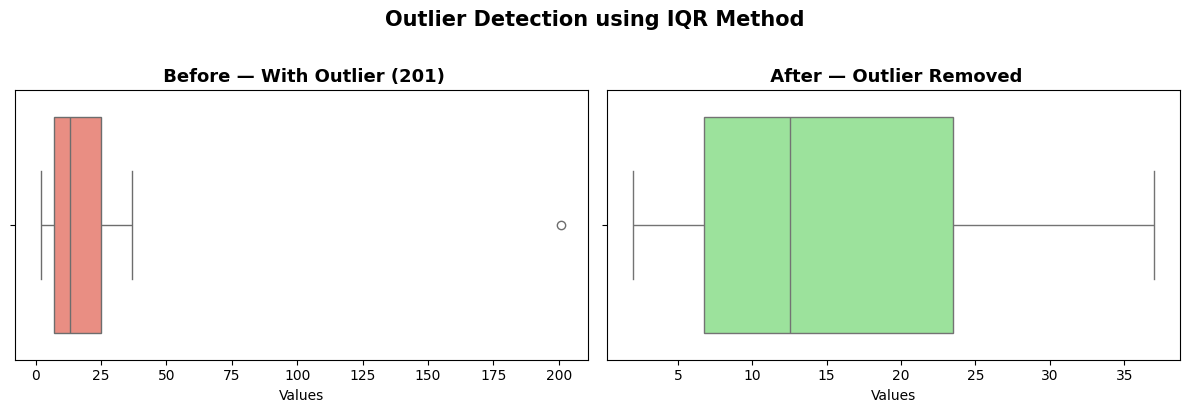

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before removing outliers
sns.boxplot(x=arr, ax=axes[0], color='salmon')
axes[0].set_title(' Before — With Outlier (201)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Values')

# After removing outliers
sns.boxplot(x=arr2, ax=axes[1], color='lightgreen')
axes[1].set_title(' After — Outlier Removed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Values')

plt.suptitle('Outlier Detection using IQR Method', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📝 Conclusion

| Metric | Before Cleaning | After Cleaning |
|---|---|---|
| Total Points | 17 | 16 |
| Min | 2 | 2 |
| Max | 201 | 37 |
| Mean | ~34.59 | ~14.56 |
| Median | 13 | 12.5 |
| Outliers | 201 | None |

---

**Interpretation:**  
The value **201** was mathematically confirmed as an outlier — it lay far beyond the **Upper Fence**.  
After removing it, the **mean dropped from 34.59 to 14.56**, much closer to the median — showing how a single outlier can heavily distort your statistics.

---

## 🔁 Methods to Handle Outliers

| Method | When to Use |
|---|---|
| **IQR Method** *(this notebook)* | General purpose, works well for skewed data |
| Z-Score Method | When data is normally distributed |
| Remove the Outlier | When it's a data entry error |
| Cap the Outlier | Replace with fence value (Winsorization) |
| Keep the Outlier | When it's a genuine rare event |

> 💡 **Key Takeaway:** Never blindly remove outliers — first **understand why they exist**. A value of 201 in height data is likely an error. But in fraud detection, the outlier IS the signal you're looking for!

